# **1. 논리 회귀**
논리 회귀(Logistic Regression)는 주어진 입력 데이터를 기반으로 두 가지 이상의 범주로 분류하는 지도 학습 알고리즘입니다. 
<br>주로 이진 분류 문제에 사용되며, 입력 변수의 선형 결합을 통해 특정 사건이 발생할 확률을 예측합니다. 
<br>이 알고리즘은 시그모이드(Sigmoid) 함수 또는 로지스틱 함수라는 비선형 함수를 사용하여 예측값을 0과 1 사이의 확률로 변환합니다. 
<br>모델의 결과는 일반적으로 특정 임계값(예: 0.5)을 기준으로 두 범주 중 하나로 분류됩니다. 
<br>예를 들어, 이메일이 스팸인지 아닌지를 판별하거나 환자의 병 진단 여부를 예측하는 데 사용될 수 있습니다. 
<br>논리 회귀는 계산이 비교적 간단하고 해석이 용이하여 머신러닝에서 널리 사용되는 알고리즘입니다.

# **2. 단항 논리 회귀**
단항 논리 회귀 (Univariate Logistic Regression)는 하나의 독립 변수(입력 변수)를 사용하여 이진 분류 문제를 해결하는 논리 회귀(Logistic Regression)의 한 형태입니다. 
<br>예를 들어, 학생의 하루 공부 시간(독립 변수)에 따라 시험 합격 여부(종속 변수: 합격/불합격)를 예측하는 경우가 여기에 해당합니다. 
<br>단항 논리 회귀는 입력 변수의 값을 시그모이드(Sigmoid) 함수에 전달하여 해당 사건(예: 합격)이 발생할 확률(0과 1 사이의 값)을 계산합니다. 
<br>이후 이 확률 값이 특정 임계값(일반적으로 0.5)을 초과하면 한 클래스로, 그렇지 않으면 다른 클래스로 분류합니다. 
<br>단항 논리 회귀는 간단하면서도 직관적이어서 이진 분류 문제를 설명하고 해석하는 데 자주 사용됩니다.

In [9]:
import torch
import torch.nn as nn

# z = W1*x1 + W2*X2 + W3*X3 + b
# x = 0.1*1.0 + 0.2*2.0+0.3*30. + 0.5
x = torch.tensor([1.0, 2.0, 3.0])
W = torch.tensor([0.1, 0.2, 0.3])
b = torch.tensor(0.5)
z = torch.dot(W, x) + b
print(z)


tensor(1.9000)


In [11]:
0.1*1.0+0.2*2.0+0.3*3.0+0.5

1.9

In [10]:
sigmoid = nn.Sigmoid()
output = sigmoid(z)
print(output)

tensor(0.8699)


```
output = model(x) # 출력 값은 logit. logit = -∞ ~ +∞
# -3.0 0.0 2.0, 5.0
# 값 자체는 범위 제한이 없기 때문에 클래스가 X일 확률이라고 해석하기 어려움
# 그래서 Sigmoid를 적용!!!
```

### ※ 시그모이드 함수

시그모이드 함수(Sigmoid Function)는 입력 값을 받아서 이를 0과 1 사이의 값으로 변환하는 수학 함수입니다. 주로 확률을 예측해야 하는 문제에서 사용됩니다. 논리 회귀(Logistic Regression)와 인공신경망(Artificial Neural Network)에서 매우 중요한 역할을 합니다. (e: 자연 상수로, 약 2.718입니다.)

![시그모이드01.png](./images/시그모이드01.png)


![시그모이드02](./images/시그모이드02.png)

In [7]:
import math

# 방법 A: math.exp() 사용 (권장: 수치 안정성이 높음)
result = 1 / (1 + math.exp(3))
print(result)  # 0.04742587317756678

# 방법 B: math.e 상수와 거듭제곱 연산자(**) 사용
result = 1 / (1 + math.e**3)
print(result)  # 0.04742587317756679

0.04742587317756678
0.04742587317756679


In [8]:
test = torch.tensor([-3.0, 0.0, 2.0, 5.0])
prob = torch.sigmoid(test)
prob

tensor([0.0474, 0.5000, 0.8808, 0.9933])

> Sigmoid는 logit의 범위를 단순히 줄이는 함수라기보다, 이진 분류에서 모델의 출력을 0 ~ 1 사이로 변환하여 클래스 1에 대한 확률처럼 해석할 수 있게 만드는 함수

In [13]:
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(2026)

x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 1])
torch.Size([8, 1])


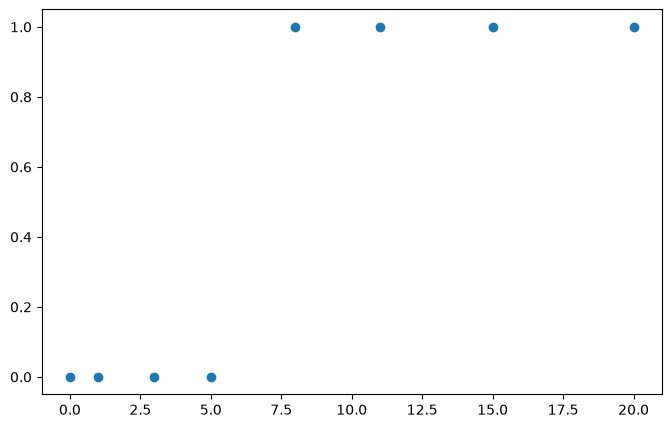

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [ ]:
model = nn.Sequential(
    nn.Linear(1, 1), # 이 수식을
    nn.Sigmoid()    # 여기에 넣겠다 통과 시키겠다
)
model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): Sigmoid()
)

In [17]:
list(model.parameters())

[Parameter containing:
 tensor([[0.4620]], requires_grad=True),
 Parameter containing:
 tensor([-0.8715], requires_grad=True)]

In [18]:
y_pred = model(x_train)
y_pred

tensor([[0.2949],
        [0.3990],
        [0.6259],
        [0.8082],
        [0.9440],
        [0.9854],
        [0.9977],
        [0.9998]], grad_fn=<SigmoidBackward0>)

### BCE 손실 함수

Binary Cross Entropy (BCE)는 이진 분류 문제에서 모델이 예측한 확률 분포와 실제 정답 레이블 사이의 차이를 측정하는 손실 함수(Loss Function)입니다. 
<br>BCE는 예측된 확률 값과 실제 값(0 또는 1) 사이의 차이를 로그 확률로 변환하여 손실을 계산합니다.

![BinaryCrossEntropy01.png](./images/BinaryCrossEntropy01.png)

![BinaryCrossEntropy02.png](./images/BinaryCrossEntropy02.png)

In [19]:
loss = nn.BCELoss()(y_pred, y_train)
loss

tensor(0.4460, grad_fn=<BinaryCrossEntropyBackward0>)

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.01) # 데이터가 한번에 싹 들어감

In [21]:
epochs = 1000

for epoch in range(1, epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 100/1000 Loss: 0.325239
Epoch: 200/1000 Loss: 0.306592
Epoch: 300/1000 Loss: 0.290278
Epoch: 400/1000 Loss: 0.275906
Epoch: 500/1000 Loss: 0.263162
Epoch: 600/1000 Loss: 0.251790
Epoch: 700/1000 Loss: 0.241584
Epoch: 800/1000 Loss: 0.232374
Epoch: 900/1000 Loss: 0.224023
Epoch: 1000/1000 Loss: 0.216414


In [22]:
list(model.parameters())

[Parameter containing:
 tensor([[0.3853]], requires_grad=True),
 Parameter containing:
 tensor([-2.0166], requires_grad=True)]

In [23]:
x_test = torch.FloatTensor([[10]])  # 위에 10이 없어서 넣음
y_pred = model(x_test)
y_pred

tensor([[0.8626]], grad_fn=<SigmoidBackward0>)

In [24]:
# 임계치 설정하기
# 0.5보다 크거나 같으면 1
# 0.5보다 작으면 0
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])

# **3. 다항 논리 회귀**
다항 논리 회귀(Multinomial Logistic Regression)는 종속 변수가 세 개 이상의 범주로 나뉘는 다중 클래스 분류 문제를 해결하는 알고리즘입니다. 
<br>예를 들어, 과일의 색깔이 빨강, 노랑, 초록 중 하나로 분류되는 문제에서 사용할 수 있습니다. 
<br>이 알고리즘은 각 클래스에 대한 확률을 예측하기 위해 소프트맥스(Softmax) 함수를 사용합니다. 
<br>소프트맥스 함수는 각 클래스에 속할 확률을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 1이 되도록 정규화합니다. 
<br>모델은 입력 데이터가 특정 클래스에 속할 가능성을 계산한 뒤, 가장 높은 확률을 가진 클래스를 최종 예측 값으로 선택합니다. 
<br>다항 논리 회귀는 자연어 처리, 이미지 분류, 그리고 다양한 다중 클래스 분류 문제에서 널리 사용됩니다.

In [ ]:
x_train = [
    # 국어, 영어, 수학, 출석
    [55, 58, 60, 70],   # C
    [60, 62, 65, 75],   # C
    [63, 65, 67, 78],   # C

    [72, 74, 75, 85],   # B
    [75, 78, 80, 88],   # B
    [80, 82, 81, 90],   # B

    [88, 90, 91, 95],   # A
    [92, 94, 93, 97],   # A
    [95, 96, 98, 98],   # A
    [98, 99, 100, 100]  # A
]

y_train = [
    0, 0, 0,    # C등급
    1, 1, 1,    # B등급
    2, 2, 2, 2  # A등급
]

x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)     # 정수형 intTensor 이런거 없음
print(x_train.shape)
print(y_train.shape)

torch.Size([10, 4])
torch.Size([10])


In [31]:
model = nn.Sequential(
    nn.Linear(4, 3),    # 독립변수 4개(국어, 영어, 수학, 출석) 들어가고 출력은 3개
)
model

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)

사진에서 W가 가중치를 나타냄 그니까 총 12개 필요함

![다항논리회귀](./images/다항논리회귀.png)

In [32]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.2775,  0.0176,  0.2332, -0.3132],
         [ 0.0050, -0.4945,  0.0246, -0.0645],
         [ 0.0433,  0.2398,  0.2096, -0.3779]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4523,  0.3276, -0.1200], requires_grad=True)]

In [33]:
y_pred = model(x_train)
y_pred

tensor([[  8.8054, -31.1145,   2.2932],
        [  9.8634, -33.2667,   2.6274],
        [ 10.2755, -34.8794,   2.7623],
        [ 12.6049, -39.5391,   4.3417],
        [ 13.7344, -41.5724,   5.3452],
        [ 14.7991, -43.6297,   5.9747],
        [ 17.9262, -47.6217,   8.4461],
        [ 18.9467, -49.6593,   9.2420],
        [ 20.6674, -50.5746,  10.5216],
        [ 21.3927, -52.1227,  11.0343]], grad_fn=<AddmmBackward0>)

# **CrossEntropyLoss**

CrossEntropyLoss는 다중 클래스 분류(Multiclass Classification) 문제에서 모델의 예측과 실제 정답 레이블 간의 차이를 측정하는 손실 함수(Loss Function)입니다. 
<br>이 함수는 모델이 예측한 확률 분포와 실제 레이블(정답) 간의 불확실성을 수치화합니다. CrossEntropyLoss는 주로 Softmax 함수와 함께 사용됩니다. 
<br>Softmax는 각 클래스에 대한 확률 분포를 제공하며, CrossEntropyLoss는 이 확률 분포와 실제 레이블 간의 차이를 계산합니다. 
<br>예측이 실제 레이블과 가까울수록 손실 값이 작아지며, 예측이 틀릴수록 손실 값은 커집니다.

![CrossEntropy](./images/CrossEntropy.png)


```
Pytorch의 nn.CrossEntropyLoss에는 Softmax와 로그 연산이; 내부적으로 포함되어 있음

1. 모델이 내놓은 값은 확률이 아니라 logit
2. Softmax를 적용하면 확률처럼 바뀜(nn.CrossEntropyLoss 포함)
3. 그래서 CrossEntropyLoss 결과에 직접 Softmax를 하지 않음
```

### Softmax

Softmax 함수는 다중 클래스 분류(Multiclass Classification) 문제에서 사용되는 활성화 함수(Activation Function)입니다. 
<br>이 함수는 주어진 입력 벡터의 각 요소를 확률 분포(probability distribution)로 변환합니다. 
<br>즉, 각 클래스에 대한 예측값을 0과 1 사이의 값으로 변환하며, 모든 클래스의 확률 합이 항상 1이 되도록 정규화합니다.



![Softmax](./images/Softmax.png)

In [34]:
loss = nn.CrossEntropyLoss()(y_pred, y_train)
loss

tensor(20.5572, grad_fn=<NllLossBackward0>)

In [35]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [36]:
epochs = 10000

for epoch in range(1, epochs + 1):
    y_pred = model(x_train)
    loss = nn.CrossEntropyLoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss: .6f}')

Epoch: 100/10000 Loss:  7.972101
Epoch: 200/10000 Loss:  59.732380
Epoch: 300/10000 Loss:  24.175083
Epoch: 400/10000 Loss:  9.984579
Epoch: 500/10000 Loss:  32.999329
Epoch: 600/10000 Loss:  22.886562
Epoch: 700/10000 Loss:  13.571785
Epoch: 800/10000 Loss:  0.000069
Epoch: 900/10000 Loss:  0.000020
Epoch: 1000/10000 Loss:  0.000013
Epoch: 1100/10000 Loss:  0.000011
Epoch: 1200/10000 Loss:  0.000010
Epoch: 1300/10000 Loss:  0.000010
Epoch: 1400/10000 Loss:  0.000010
Epoch: 1500/10000 Loss:  0.000010
Epoch: 1600/10000 Loss:  0.000009
Epoch: 1700/10000 Loss:  0.000009
Epoch: 1800/10000 Loss:  0.000009
Epoch: 1900/10000 Loss:  0.000009
Epoch: 2000/10000 Loss:  0.000009
Epoch: 2100/10000 Loss:  0.000009
Epoch: 2200/10000 Loss:  0.000009
Epoch: 2300/10000 Loss:  0.000009
Epoch: 2400/10000 Loss:  0.000009
Epoch: 2500/10000 Loss:  0.000009
Epoch: 2600/10000 Loss:  0.000009
Epoch: 2700/10000 Loss:  0.000009
Epoch: 2800/10000 Loss:  0.000009
Epoch: 2900/10000 Loss:  0.000009
Epoch: 3000/10000 

In [37]:
x_test = torch.FloatTensor([[90, 91, 92, 93]])
y_pred = model(x_test)
y_pred

tensor([[-72.1203,   4.6915,  48.5401]], grad_fn=<AddmmBackward0>)

In [38]:
y_prob = nn.Softmax(1)(y_pred)  # 1은 축방향으로 1이 나올 수 있도록 정함
y_prob

tensor([[0.0000e+00, 9.0525e-20, 1.0000e+00]], grad_fn=<SoftmaxBackward0>)

In [39]:
print(f'0일 확률: {y_prob[0][0]:.2f}')
print(f'1일 확률: {y_prob[0][1]:.2f}')
print(f'2일 확률: {y_prob[0][2]:.2f}')

0일 확률: 0.00
1일 확률: 0.00
2일 확률: 1.00


In [40]:
torch.argmax(y_prob, axis=1)

tensor([2])